# Q5 — Favorite Programming Language by Role and Industry

**Question:** Which programming language is most popular, broken down by role and industry?

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.dpi"] = 110

OUT = Path("charts")
OUT.mkdir(exist_ok=True)

# Load and clean - same cleaning decision made in the SQL phase:
# blank education values become the literal string 'None'
df = pd.read_csv("DataProfessionalSurvey_Clean.csv")
df["education"] = df["education"].fillna("None")
df["country"] = df["country"].str.strip()
df["role_name"] = df["role_name"].str.strip()

print(f"{len(df)} respondents loaded.")
df.head()

630 respondents loaded.


,respondent_id,date_taken,time_taken,time_spent,role_name,switched_careers,salary_band,salary_midpoint,industry,fav_language,...,satisfaction_mobility,satisfaction_learning,satisfaction_composite,difficulty_breaking_in,top_job_priority,gender,age,country,education,ethnicity
0,62a33b3db4da29969c62df3d,6/10/2022,8:38,0:00:44,Data Analyst,Yes,106-125,115500,Healthcare,Python,...,5.00,7.00,7.00,Very Difficult,Remote Work,Male,26,United States,None,White
1,62a33ba1bae91e4b8b82e35c,6/10/2022,8:40,0:01:30,Data Analyst,No,41-65,53000,Finance,R,...,1.00,3.00,2.33,Very Difficult,Remote Work,Male,36,Canada,None,Asian
2,62a33c2cbc6861bf3176bec1,6/10/2022,8:42,0:02:18,Data Engineer,No,0-40,20000,Other,Python,...,7.00,7.00,5.67,Easy,Good Work/Life Balance,Male,23,Rest of the world,None,Black
3,62a33c8624a26260273822f9,6/10/2022,8:43,0:02:10,Other,Yes,150 - 225,187500,Finance,R,...,7.00,10.00,8.33,Very Easy,Remote Work,Female,35,Canada,None,White
4,62a33c91f3072dd892621e03,6/10/2022,8:44,0:01:51,Data Analyst,Yes,41 - 65,53000,Healthcare,R,...,0.00,1.00,2.33,Difficult,Better Salary,Male,44,United States,None,Black


### Overall popularity

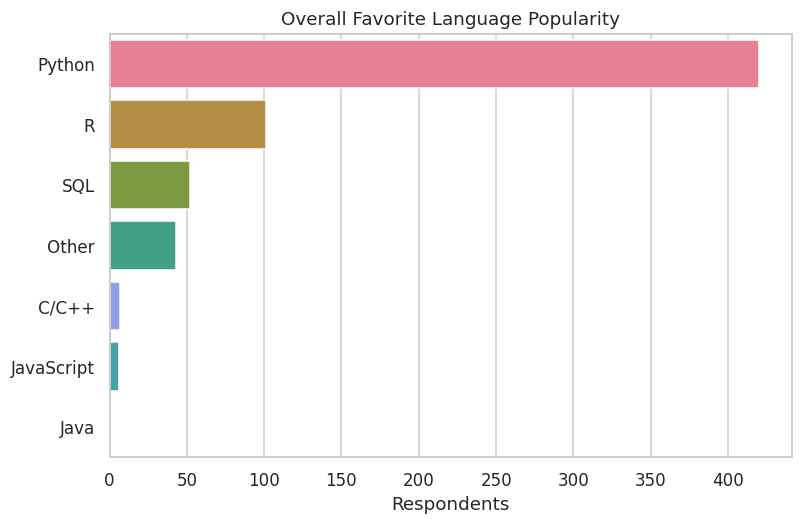

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
order = df["fav_language"].value_counts().index
sns.countplot(data=df, y="fav_language", order=order, ax=ax, hue="fav_language", legend=False)
ax.set_title("Overall Favorite Language Popularity")
ax.set_xlabel("Respondents")
ax.set_ylabel("")
fig.savefig(OUT / "q5_language_popularity.png", bbox_inches="tight")
plt.show()

### Top language per role

In [3]:
lang_by_role = pd.crosstab(df["role_name"], df["fav_language"])
top_lang_per_role = pd.DataFrame({
    "top_language": lang_by_role.idxmax(axis=1),
    "votes": lang_by_role.max(axis=1),
})
top_lang_per_role

,top_language,votes
role_name,,
Data Analyst,Python,255
Data Architect,Python,3
Data Engineer,Python,29
Data Scientist,Python,20
Database Developer,Python,3
Other,Python,54


### Language by industry (stacked)

In [4]:
lang_by_industry = pd.crosstab(df["industry"], df["fav_language"])
lang_by_industry

fav_language,C/C++,Java,JavaScript,Other,Python,R,SQL
industry,,,,,,,
Agriculture,0,0,0,0,4,0,3
Construction,0,0,0,4,7,3,0
Education,0,0,0,1,24,8,5
Finance,2,0,0,8,70,8,9
Healthcare,1,0,1,10,47,18,7
Other,2,1,4,17,131,34,16
Real Estate,0,0,0,0,9,3,1
Tech,2,0,1,1,113,24,9
Telecommunication,0,0,0,2,15,3,2


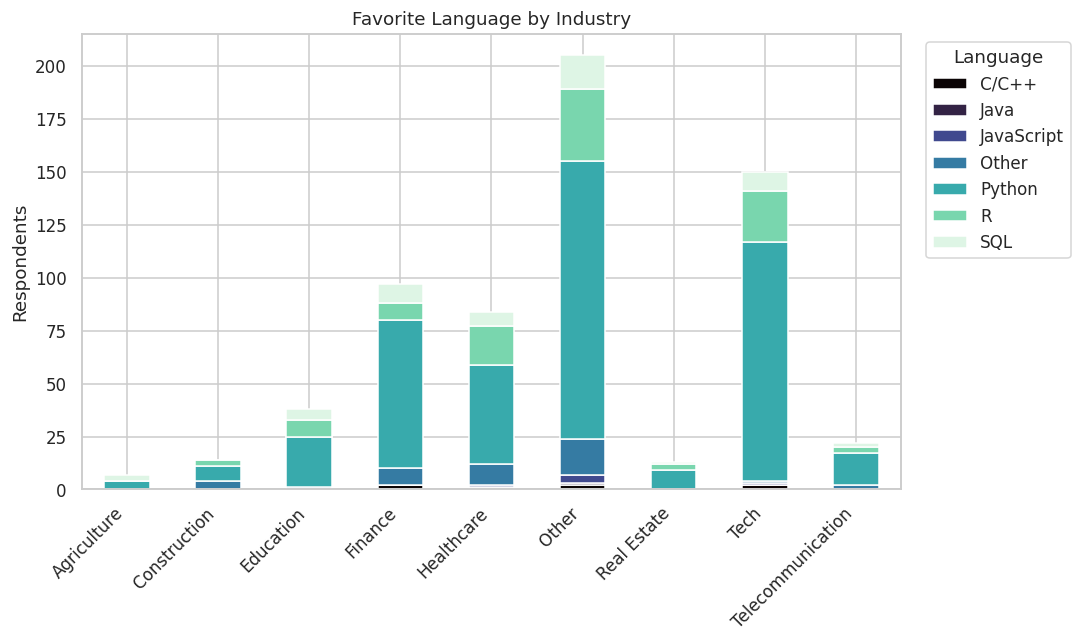

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
lang_by_industry.plot(kind="bar", stacked=True, ax=ax, colormap="mako")
ax.set_title("Favorite Language by Industry")
ax.set_ylabel("Respondents")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
ax.legend(title="Language", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(OUT / "q5_language_by_industry_stacked.png", bbox_inches="tight")
plt.show()

**Takeaway:** Python dominates every role and every industry by a wide margin; SQL and R trail as distant seconds.

# Q5b — Most and Least Common Language per Role

**Question:** For each role, what's the single most popular language, and what's the least popular (a distinct ranking question from overall popularity)?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.dpi"] = 110

OUT = Path("charts")
OUT.mkdir(exist_ok=True)

df = pd.read_csv("DataProfessionalSurvey_Clean.csv")
df["education"] = df["education"].fillna("None")
df["country"] = df["country"].str.strip()
df["role_name"] = df["role_name"].str.strip()

DIMS = ["satisfaction_salary", "satisfaction_worklife", "satisfaction_coworkers",
        "satisfaction_management", "satisfaction_mobility", "satisfaction_learning"]

print(f"{len(df)} respondents loaded.")
df.head()

630 respondents loaded.


,respondent_id,date_taken,time_taken,time_spent,role_name,switched_careers,salary_band,salary_midpoint,industry,fav_language,...,satisfaction_mobility,satisfaction_learning,satisfaction_composite,difficulty_breaking_in,top_job_priority,gender,age,country,education,ethnicity
0,62a33b3db4da29969c62df3d,6/10/2022,8:38,0:00:44,Data Analyst,Yes,106-125,115500,Healthcare,Python,...,5.00,7.00,7.00,Very Difficult,Remote Work,Male,26,United States,None,White
1,62a33ba1bae91e4b8b82e35c,6/10/2022,8:40,0:01:30,Data Analyst,No,41-65,53000,Finance,R,...,1.00,3.00,2.33,Very Difficult,Remote Work,Male,36,Canada,None,Asian
2,62a33c2cbc6861bf3176bec1,6/10/2022,8:42,0:02:18,Data Engineer,No,0-40,20000,Other,Python,...,7.00,7.00,5.67,Easy,Good Work/Life Balance,Male,23,Rest of the world,None,Black
3,62a33c8624a26260273822f9,6/10/2022,8:43,0:02:10,Other,Yes,150 - 225,187500,Finance,R,...,7.00,10.00,8.33,Very Easy,Remote Work,Female,35,Canada,None,White
4,62a33c91f3072dd892621e03,6/10/2022,8:44,0:01:51,Data Analyst,Yes,41 - 65,53000,Healthcare,R,...,0.00,1.00,2.33,Difficult,Better Salary,Male,44,United States,None,Black


### Most and least common favorite language, per role

In [3]:
lang_by_role = pd.crosstab(df["role_name"], df["fav_language"])

results = []
for role in lang_by_role.index:
    counts = lang_by_role.loc[role]
    counts = counts[counts > 0]  # ignore languages with zero respondents for that role
    most_lang, most_n = counts.idxmax(), counts.max()
    least_lang, least_n = counts.idxmin(), counts.min()
    results.append({"role_name": role, "most_common": most_lang, "most_votes": most_n,
                     "least_common": least_lang, "least_votes": least_n})

most_least_language = pd.DataFrame(results).set_index("role_name")
most_least_language

,most_common,most_votes,least_common,least_votes
role_name,,,,
Data Analyst,Python,255,C/C++,5
Data Architect,Python,3,Python,3
Data Engineer,Python,29,JavaScript,2
Data Scientist,Python,20,SQL,1
Database Developer,Python,3,SQL,2
Other,Python,54,Java,1


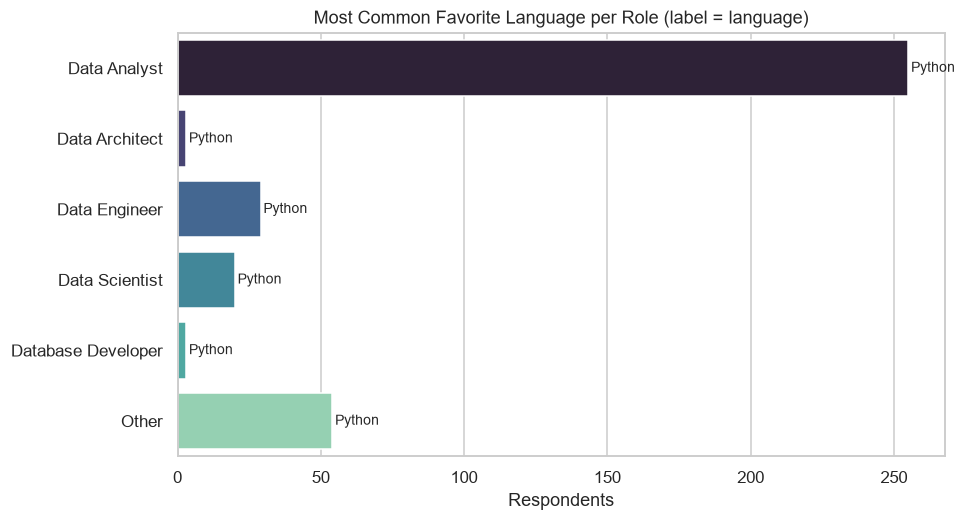

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
data = most_least_language.reset_index()
sns.barplot(data=data, y="role_name", x="most_votes", ax=ax, hue="role_name", legend=False)
for i, row in data.iterrows():
    ax.text(row["most_votes"] + 1, i, row["most_common"], va="center", fontsize=9)
ax.set_title("Most Common Favorite Language per Role (label = language)")
ax.set_xlabel("Respondents")
ax.set_ylabel("")
fig.savefig(OUT / "q5b_most_common_language_per_role.png", bbox_inches="tight")
plt.show()

**Takeaway:** Python is the most common language for almost every role, so the more interesting signal is in the *least* common column — it shows which languages have essentially zero footprint in each role, useful for spotting roles with more language diversity vs roles that are Python-only in practice.